In [1]:
%pip install yfinance
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import seaborn as sns
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
tickers = ['PERSISTENT.NS', 'BAJAJ-AUTO.NS', 'AXISBANK.NS', 'LUPIN.NS', 'MARICO.NS', 'SRF.NS', 'SIEMENS.NS', 'BAJFINANCE.NS' ]
data = yf.download(tickers, start='2021-9-18', end='2026-9-18', auto_adjust=False)
data = data.dropna()

[*********************100%***********************]  8 of 8 completed


In [4]:
adj_close = data['Adj Close']
adj_close.head()

Ticker,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,LUPIN.NS,MARICO.NS,PERSISTENT.NS,SIEMENS.NS,SRF.NS
Date,,,,,,,,
2021-09-20,791.929993,3368.868408,725.751831,907.688110,531.744751,1700.438965,1224.262939,2087.839355
2021-09-21,791.432556,3326.713623,761.968994,904.139954,525.419556,1723.789917,1243.346802,2099.029053
2021-09-22,784.466980,3352.006348,759.999207,913.763672,529.636230,1789.605225,1238.991455,2112.107910
2021-09-23,808.149841,3389.521973,770.277222,914.103943,531.135620,1816.061401,1239.421265,2164.887451
2021-09-24,794.119324,3398.979248,759.974731,900.348816,522.280273,1807.587524,1215.093628,2167.879395


In [5]:
daily_returns = adj_close.pct_change(1).fillna(0) * 100

daily_returns.head()

Ticker,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,LUPIN.NS,MARICO.NS,PERSISTENT.NS,SIEMENS.NS,SRF.NS
Date,,,,,,,,
2021-09-20,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-09-21,-0.062813,-1.251304,4.990296,-0.390900,-1.189517,1.373231,1.558804,0.535946
2021-09-22,-0.880123,0.760292,-0.258513,1.064406,0.802535,3.818059,-0.350292,0.623091
2021-09-23,3.018975,1.119199,1.352372,0.037238,0.283098,1.478325,0.034690,2.498904
2021-09-24,-1.736128,0.279015,-1.337504,-1.504766,-1.667248,-0.466607,-1.962822,0.138203


In [6]:
def plot_financial_data(df, title):
    fig = px.line(title = title)
    for i in df.columns[1:]:
        fig.add_scatter(x = df['Date'], y = df[i], name = i)
        fig.update_traces(line_width = 5)
        fig.update_layout({'plot_bgcolor': "white"})
    fig.show()

In [7]:
adj_close_reset = adj_close.reset_index()
plot_financial_data(adj_close_reset, 'Portfolio Stocks - Adjusted Closing Price (in rupees)')

In [8]:
daily_returns_reset = daily_returns.reset_index()
plot_financial_data(daily_returns_reset, 'Portfolio Stocks Daily Returns(in rupees)')

In [9]:
fig = px.histogram(daily_returns_reset.drop(columns = ['Date']))
fig.update_layout({'plot_bgcolor' : 'white'})
fig.show()

<Axes: xlabel='Ticker', ylabel='Ticker'>

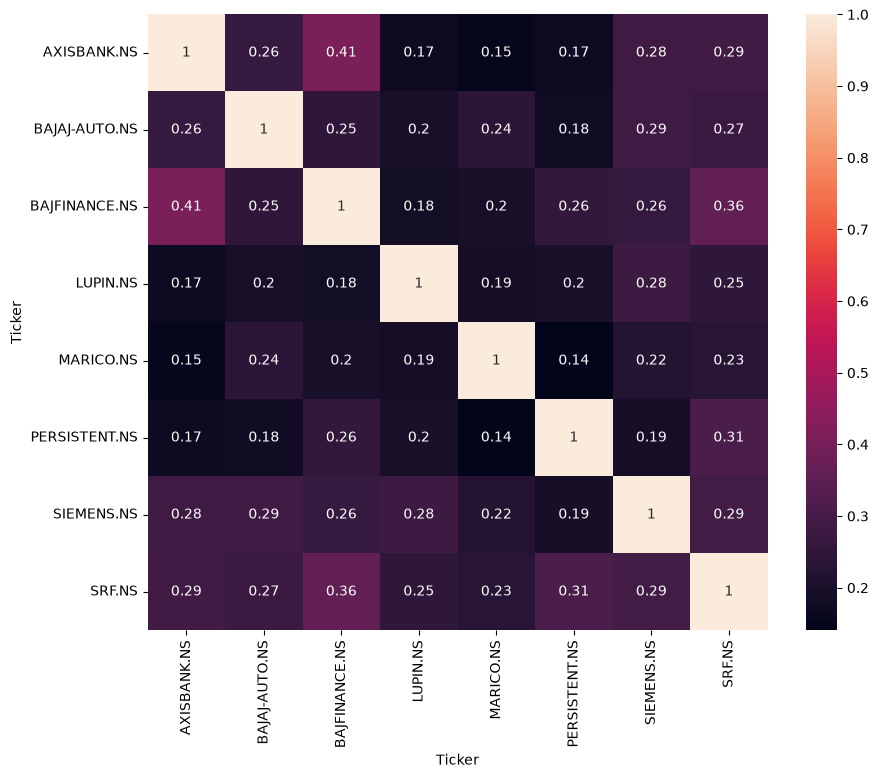

In [10]:
plt.figure(figsize = (10,8))
sns.heatmap(daily_returns_reset.drop(columns = ['Date']).corr(),annot = True)

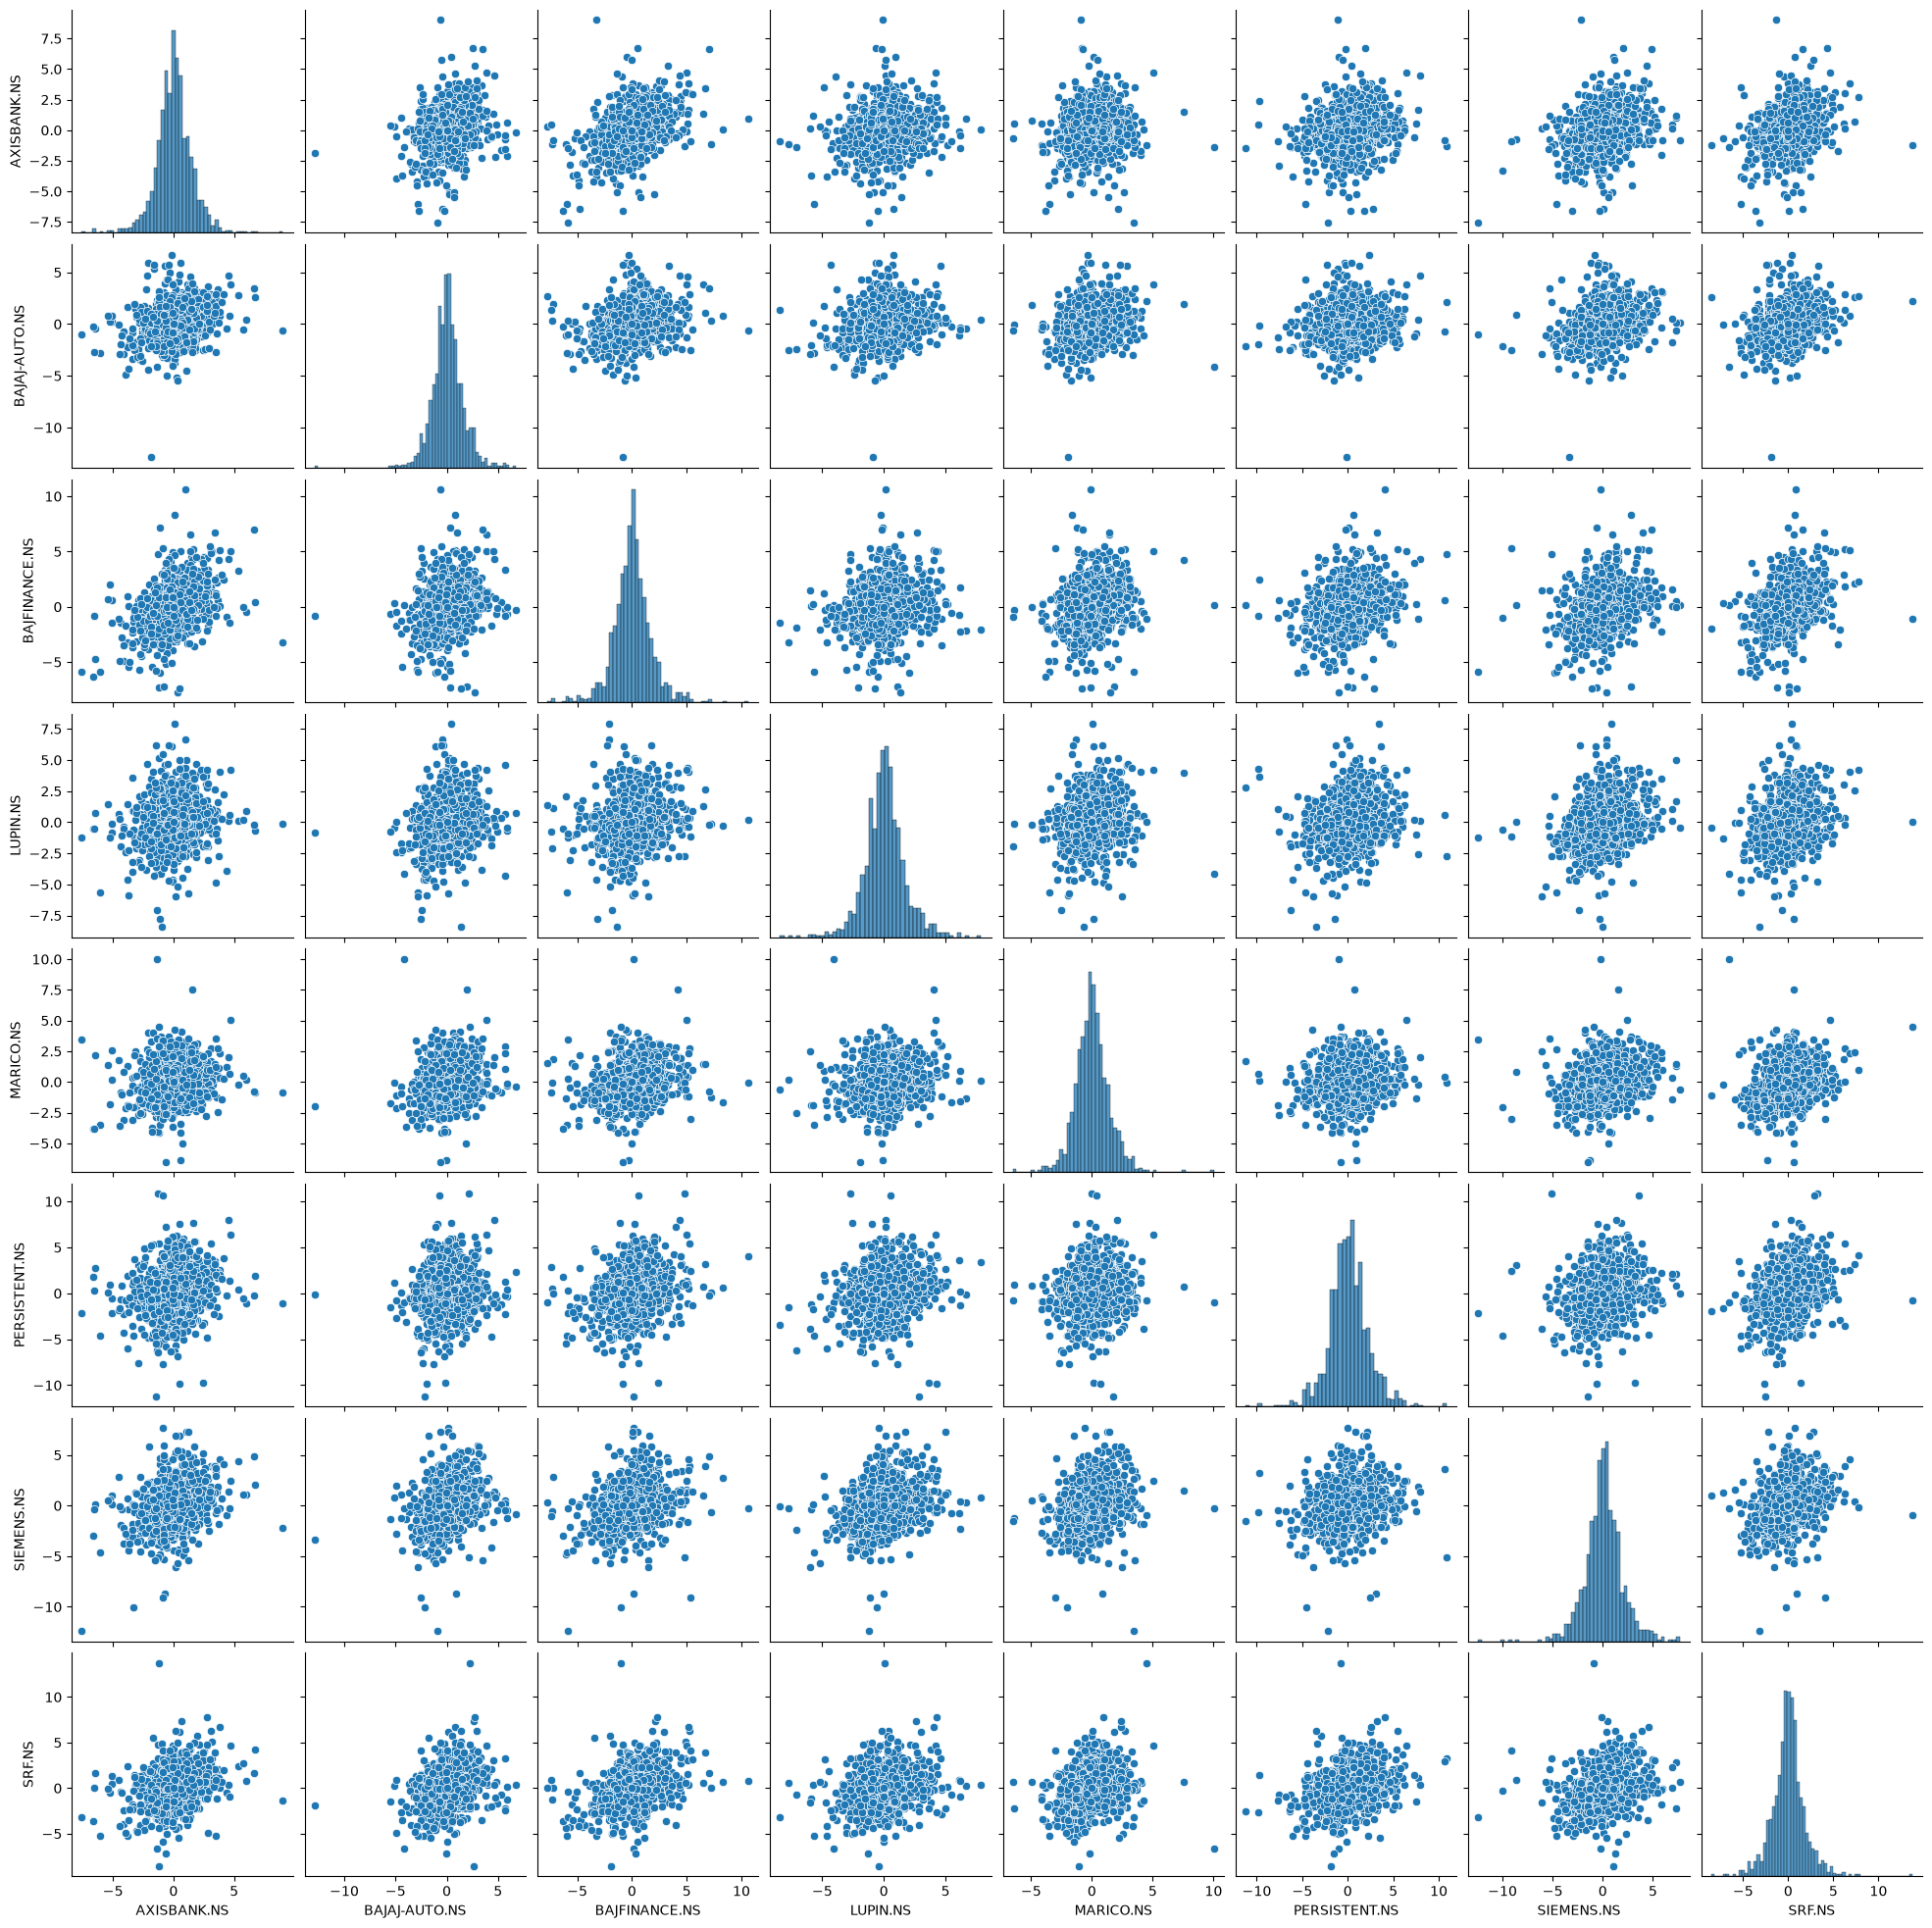

In [11]:
sns.pairplot(daily_returns_reset.drop(columns = ['Date']))

In [12]:
def price_scaling(raw_price_df):
    scaled_price_df = raw_price_df.copy()
    for i in raw_price_df.columns[1:]:
        scaled_price_df[i] = raw_price_df[i]/raw_price_df[i][0]
    return scaled_price_df

price_scaling(adj_close_reset)

Ticker,Date,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,LUPIN.NS,MARICO.NS,PERSISTENT.NS,SIEMENS.NS,SRF.NS
0,2021-09-20,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2021-09-21,0.999372,0.987487,1.049903,0.996091,0.988105,1.013732,1.015588,1.005359
2,2021-09-22,0.990576,0.994995,1.047189,1.006693,0.996035,1.052437,1.012031,1.011624
3,2021-09-23,1.020481,1.006131,1.061351,1.007068,0.998854,1.067996,1.012382,1.036903
4,2021-09-24,1.002765,1.008938,1.047155,0.991914,0.982201,1.063012,0.992510,1.038336
...,...,...,...,...,...,...,...,...,...
1234,2026-09-11,1.573371,3.466446,1.425418,2.308062,1.508430,3.243868,3.232149,1.188980
1235,2026-09-14,1.573371,3.466446,1.425418,2.308062,1.508430,3.243868,3.232149,1.188980
1236,2026-09-15,1.544202,3.391050,1.390558,2.273027,1.488026,3.221227,3.079404,1.175953
1237,2026-09-16,1.567058,3.441215,1.386424,2.252977,1.523569,3.199174,3.056533,1.187879


In [13]:
plot_financial_data(price_scaling(adj_close_reset),'Scaled Stock Prices (Starting at 1)')

In [14]:
import random
random.seed(42)
np.random.seed(42)

def generate_portfolio_weights(n):
    #This generates n random numbers as raw and are not normalized weights    
    weights = []
    for i in range(n):
        weights.append(random.random())
        
    # Normalize so all weights sum to 1(i.e 100% of portfolio)
    # Weights are positive, so it is of Long-Only Portfolio     
    weights = weights/np.sum(weights)
    return weights

In [15]:
weights = generate_portfolio_weights(8)
weights.round(6)


array([0.179869, 0.007035, 0.077365, 0.062788, 0.207167, 0.190353,
       0.250967, 0.024456])

In [16]:
weights = [0.072033, 0.21866 , 0.136594, 0.012709, 0.050304, 0.185003,
       0.192156, 0.132542]
print(sum(weights))

1.000001


In [17]:
def asset_allocation(df, weights, initial_investment):
    portfolio_df = df.copy()
    # This scales all stock prices to start at 1, so they're comparable with no-relationship with price levels
    scaled_df = price_scaling(df)

    # Convert each stock's scaled price into a rupee value based on its weight and total investment
    for i, stock in enumerate(scaled_df.columns[1:]):
        portfolio_df[stock] = scaled_df[stock] * weights[i] * initial_investment

    # This sums of all individual stock values on every single day
    portfolio_df['Portfolio Value'] = portfolio_df.loc[:, portfolio_df.columns != 'Date'].sum(axis=1, numeric_only=True)

    # Calculating Daily % change in total portfolio value with .pct_change
    portfolio_df['Portfolio Daily Return [%]'] = portfolio_df['Portfolio Value'].pct_change(1) * 100
    portfolio_df.replace(np.nan, 0, inplace=True)

    return portfolio_df

In [18]:
n = len(adj_close_reset.columns) - 1
print('Number of stocks under consideration = {}'.format(n))

weights = generate_portfolio_weights(n).round(6)
print('Portfolio weights = {}'.format(weights))

portfolio_df = asset_allocation(adj_close_reset, weights, 1000000)
portfolio_df.round(2)

Number of stocks under consideration = 8
Portfolio weights = [0.162533 0.011479 0.084224 0.194674 0.010222 0.076596 0.250349 0.209923]


C:\Users\Mayank\AppData\Local\Temp\ipykernel_11760\1957144160.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  portfolio_df.round(2)


Ticker,Date,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,LUPIN.NS,MARICO.NS,PERSISTENT.NS,SIEMENS.NS,SRF.NS,Portfolio Value,Portfolio Daily Return [%]
0,2021-09-20,162533.00,11479.00,84224.00,194674.00,10222.00,76596.00,250349.00,209923.00,1000000.00,0.00
1,2021-09-21,162430.91,11335.36,88427.03,193913.02,10100.41,77647.84,254251.45,211048.07,1009154.09,0.92
2,2021-09-22,161001.32,11421.54,88198.43,195977.04,10181.47,80612.48,253360.83,212363.10,1013116.20,0.39
3,2021-09-23,165861.91,11549.37,89391.20,196050.02,10210.29,81804.19,253448.72,217669.84,1025985.55,1.27
4,2021-09-24,162982.33,11581.60,88195.59,193099.92,10040.06,81422.49,248473.97,217970.67,1013766.64,-1.19
...,...,...,...,...,...,...,...,...,...,...,...
1234,2026-09-11,255724.77,39791.33,120054.44,449319.57,15419.18,248467.33,809165.22,249594.32,2187536.16,-0.02
1235,2026-09-14,255724.77,39791.33,120054.44,449319.57,15419.18,248467.33,809165.22,249594.32,2187536.16,0.00
1236,2026-09-15,250983.81,38925.86,117118.36,442499.34,15210.60,246733.11,770925.67,246859.48,2129256.23,-2.66
1237,2026-09-16,254698.59,39501.71,116770.20,438595.95,15573.93,245043.93,765199.96,249363.08,2124747.35,-0.21


In [19]:
plot_financial_data(portfolio_df[['Date', 'Portfolio Daily Return [%]']], 'Portfolio Percentage Daily Return')

In [20]:
plot_financial_data(portfolio_df.drop(['Portfolio Value', 'Portfolio Daily Return [%]'], axis = 1), 'Portfolio Position')

In [21]:
plot_financial_data(portfolio_df[['Date', 'Portfolio Value']], 'Total Portfolio Value')

In [22]:
def simulation_engine(weights, initial_investment):
    portfolio_df = asset_allocation(adj_close_reset, weights, initial_investment)
    
    # calculate how much we made (or lost) from day 1 to the last day, overall
    return_on_investment = ((portfolio_df['Portfolio Value'][-1:]-
                             portfolio_df['Portfolio Value'][0])/
                            portfolio_df['Portfolio Value'][0]) * 100
    portfolio_daily_return_df = portfolio_df.drop(columns = ['Date', 'Portfolio Value', 'Portfolio Daily Return [%]'])
    portfolio_daily_return_df = portfolio_daily_return_df.pct_change(1)
    
    # taking average daily return and scaling it up to a full year (252 trading days)
    expected_portfolio_return = np.sum(weights * portfolio_daily_return_df.mean()) * 252
    
    # this tells how much the stocks move together, scaled to a year too, i.e; the risk part
    covariance = portfolio_daily_return_df.cov() * 252
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))
    
    # this is the India's 5-year bond yield
    rf = 0.06674
    
    # sharpe ratio to calculate and know that are we getting paid enough for the risk we're taking?
    sharpe_ratio = (expected_portfolio_return - rf)/expected_volatility
    
    return expected_portfolio_return, expected_volatility, sharpe_ratio, portfolio_df['Portfolio Value'][-1:].values[0], return_on_investment.values[0]

In [23]:
initial_investments = 1000000
portfolio_metrics = simulation_engine(weights, initial_investments)

In [24]:
print('Expected Portfolio Annual Return = {:.2f}%'.format(portfolio_metrics[0] * 100))
print('Portfolio Standard Deviation (Volatility) = {:.2f}%'.format(portfolio_metrics[1] * 100))
print('Sharpe Ratio = {:.2f}'.format(portfolio_metrics[2]))
print('Portfolio Final Value = ₹{:.2f}'.format(portfolio_metrics[3]))
print('Return on Investment = {:.2f}%'.format(portfolio_metrics[4]))

Expected Portfolio Annual Return = 18.15%
Portfolio Standard Deviation (Volatility) = 17.81%
Sharpe Ratio = 0.64
Portfolio Final Value = ₹2148270.15
Return on Investment = 114.83%


In [25]:
sim_runs = 10000 # running 10000 simulations to find better chance of a good mix of weights for portfolio
initial_investments = 1000000

weights_runs = np.zeros((sim_runs, n))

sharpe_ratio_runs = np.zeros(sim_runs)

expected_portfolio_returns_runs = np.zeros(sim_runs)

volatility_runs = np.zeros(sim_runs)

return_on_investment_runs = np.zeros(sim_runs)

final_value_runs = np.zeros(sim_runs)

import time
start = time.time() # starting the clock before the loop starts

# basically just guessing 10,000 different stock mixes and checking which one works best
# It does not using any brute math to solve it directly, just using trial and error
for i in range(sim_runs):
    weights = generate_portfolio_weights(n)
    weights_runs[i,:] = weights
    
    expected_portfolio_returns_runs[i], volatility_runs[i], sharpe_ratio_runs[i], final_value_runs[i], return_on_investment_runs[i] = simulation_engine(weights, initial_investments)
    

In [26]:
end = time.time()
print('Simulation time in seconds: {:.4f}'.format(end - start))

best_sharpe_idx = sharpe_ratio_runs.argmax()

print('\nBest Sharpe Ratio = {:.4f}'.format(sharpe_ratio_runs[best_sharpe_idx]))
print('Best Weights = {}'.format([f'{w*100:.4f}%' for w in weights_runs[best_sharpe_idx]]))
print('Expected Return = {:.4f}%'.format(expected_portfolio_returns_runs[best_sharpe_idx] * 100))
print('Volatility = {:.4f}%'.format(volatility_runs[best_sharpe_idx] * 100))
print('Final Portfolio Value = ₹{:.4f}'.format(final_value_runs[best_sharpe_idx]))

Simulation time in seconds: 163.7667

Best Sharpe Ratio = 1.0388
Best Weights = ['6.1913%', '36.5147%', '1.0912%', '15.1320%', '3.7599%', '29.9998%', '7.0794%', '0.2317%']
Expected Return = 25.5211%
Volatility = 18.1436%
Final Portfolio Value = ₹2952224.8449


In [27]:
sharpe_ratio_runs.argmax()

np.int64(4208)

In [28]:
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 'Portfolio Returns': expected_portfolio_returns_runs.tolist(), 'Sharpe Ratio': sharpe_ratio_runs.tolist() })
sim_out_df

,Volatility,Portfolio Returns,Sharpe Ratio
0,0.166958,0.188927,0.731845
1,0.163925,0.177821,0.677634
2,0.157873,0.197372,0.827445
3,0.170046,0.158558,0.539959
4,0.174945,0.197646,0.748270
...,...,...,...
9995,0.166673,0.184471,0.706360
9996,0.158472,0.185026,0.746420
9997,0.173086,0.218087,0.874402
9998,0.168922,0.190989,0.735541


In [29]:
import plotly.graph_objects as go
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio Returns', color = 'Sharpe Ratio', size = 'Sharpe Ratio', hover_data = ['Sharpe Ratio'] )
fig.update_layout({'plot_bgcolor': "white"})
fig.show()

In [30]:
optimal_volatility = volatility_runs[best_sharpe_idx]
optimal_portfolio_return = expected_portfolio_returns_runs[best_sharpe_idx]

In [31]:
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio Returns', color = 'Sharpe Ratio', size = 'Sharpe Ratio', hover_data = ['Sharpe Ratio'] )
fig.add_trace(go.Scatter(x = [optimal_volatility], y = [optimal_portfolio_return], mode = 'markers', name = 'Optimal Point', marker = dict(size=[40], color = 'red')))
fig.update_layout(coloraxis_colorbar = dict(y = 0.7, dtick = 5))
fig.update_layout({'plot_bgcolor': "white"})
fig.show()


print('Simulation time in seconds: {:.4f}'.format(end - start))
print('\nBest Sharpe Ratio = {:.4f}'.format(sharpe_ratio_runs[best_sharpe_idx]))
print('Best Weights = {}'.format([f'{w*100:.4f}%' for w in weights_runs[best_sharpe_idx]]))
print('Expected Return = {:.4f}%'.format(expected_portfolio_returns_runs[best_sharpe_idx] * 100))
print('Volatility = {:.4f}%'.format(volatility_runs[best_sharpe_idx] * 100))
print('Final Portfolio Value = ₹{:.4f}'.format(final_value_runs[best_sharpe_idx]))

Simulation time in seconds: 163.7667

Best Sharpe Ratio = 1.0388
Best Weights = ['6.1913%', '36.5147%', '1.0912%', '15.1320%', '3.7599%', '29.9998%', '7.0794%', '0.2317%']
Expected Return = 25.5211%
Volatility = 18.1436%
Final Portfolio Value = ₹2952224.8449


In [32]:
# splitting by date, not using random dates 
# training python with older data and testing on newer data that the model hasn't "seen" yet
split_date = '2024-09-18'  

adj_close_reset_train = adj_close_reset[adj_close_reset['Date'] < split_date].reset_index(drop=True)
adj_close_reset_test = adj_close_reset[adj_close_reset['Date'] >= split_date].reset_index(drop=True)

print(f"Train period: {adj_close_reset_train['Date'].min()} to {adj_close_reset_train['Date'].max()}")
print(f"Test period: {adj_close_reset_test['Date'].min()} to {adj_close_reset_test['Date'].max()}")

Train period: 2021-09-20 00:00:00 to 2024-09-17 00:00:00
Test period: 2024-09-18 00:00:00 to 2026-09-17 00:00:00


In [33]:
def simulation_engine_2(price_df, weights, initial_investment):
    portfolio_df = asset_allocation(price_df, weights, initial_investment)
    
    return_on_investment = ((portfolio_df['Portfolio Value'][-1:] -
                             portfolio_df['Portfolio Value'][0]) /
                            portfolio_df['Portfolio Value'][0]) * 100
    portfolio_daily_return_df = portfolio_df.drop(columns=['Date', 'Portfolio Value', 'Portfolio Daily Return [%]'])
    portfolio_daily_return_df = portfolio_daily_return_df.pct_change(1)
    
    expected_portfolio_return = np.sum(weights * portfolio_daily_return_df.mean()) * 252
    covariance = portfolio_daily_return_df.cov() * 252
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))
    
    rf = 0.06674
    sharpe_ratio = (expected_portfolio_return - rf) / expected_volatility
    
    return expected_portfolio_return, expected_volatility, sharpe_ratio, portfolio_df['Portfolio Value'][-1:].values[0], return_on_investment.values[0]

In [34]:
sim_runs = 10000
initial_investments = 1000000

weights_runs_train = np.zeros((sim_runs, n))
sharpe_ratio_runs_train = np.zeros(sim_runs)
expected_portfolio_returns_runs_train = np.zeros(sim_runs)
volatility_runs_train = np.zeros(sim_runs)

# doing the same 10,000 guess again, but only using the older (train) data
# this way the model has no data of 2025-2026 to keep it fair
for i in range(sim_runs):
    weights = generate_portfolio_weights(n)
    weights_runs_train[i, :] = weights
    
    expected_portfolio_returns_runs_train[i], volatility_runs_train[i], sharpe_ratio_runs_train[i], _, _ = simulation_engine_2(adj_close_reset_train, weights, initial_investments)

best_sharpe_idx_train = sharpe_ratio_runs_train.argmax()
# weights are locked and not changing them again after this
best_weights = weights_runs_train[best_sharpe_idx_train]

print('Best Sharpe Ratio (TRAIN) = {:.4f}'.format(sharpe_ratio_runs_train[best_sharpe_idx_train]))
print('Best Weights (TRAIN) = {}'.format([f'{w*100:.2f}%' for w in best_weights]))

Best Sharpe Ratio (TRAIN) = 1.8754
Best Weights (TRAIN) = ['2.97%', '29.74%', '0.03%', '24.01%', '3.86%', '3.97%', '33.49%', '1.95%']


In [35]:
# using the exact same weights from before to check the data works with the data they haven't seen
# here no re-optimizing on the new data
test_return, test_volatility, test_sharpe, test_final_value, test_roi = simulation_engine_2(adj_close_reset_test, best_weights, initial_investments)

print('\n--- TEST RESULTS (using weights frozen from train) ---')
print('Sharpe Ratio (TEST) = {:.4f}'.format(test_sharpe))
print('Expected Return (TEST) = {:.2f}%'.format(test_return * 100))
print('Volatility (TEST) = {:.2f}%'.format(test_volatility * 100))


--- TEST RESULTS (using weights frozen from train) ---
Sharpe Ratio (TEST) = -0.1629
Expected Return (TEST) = 3.54%
Volatility (TEST) = 19.21%


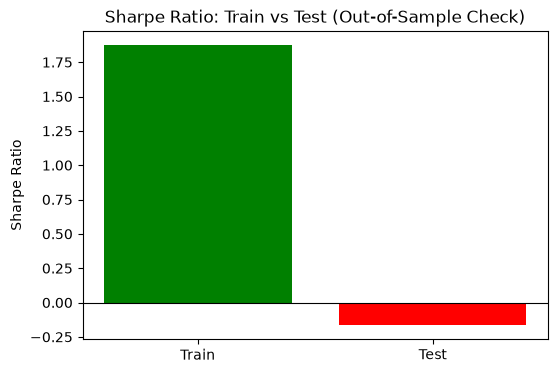

Best Sharpe Ratio (TRAIN) = 1.8754
Sharpe Ratio (TEST) = -0.1629


In [36]:
import matplotlib.pyplot as plt

labels = ['Train', 'Test']
sharpe_values = [sharpe_ratio_runs_train[best_sharpe_idx_train], test_sharpe]

plt.figure(figsize=(6,4))
plt.bar(labels, sharpe_values, color=['green', 'red'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Sharpe Ratio: Train vs Test (Out-of-Sample Check)')
plt.ylabel('Sharpe Ratio')
plt.show()

print('Best Sharpe Ratio (TRAIN) = {:.4f}'.format(sharpe_ratio_runs_train[best_sharpe_idx_train]))
print('Sharpe Ratio (TEST) = {:.4f}'.format(test_sharpe))

In [37]:
print("\n--- SUMMARY ---")
print(f"In-sample (train) Sharpe Ratio : {sharpe_ratio_runs_train[best_sharpe_idx_train]:.4f}")
print(f"Out-of-sample (test) Sharpe Ratio: {test_sharpe:.4f}")
print("\nKey takeaway: the Sharpe Ratio dropped from train to test, which is expected —")
print("it shows the 'optimal' weights found on historical data don't perform identically")
print("on unseen data, a real check against overfitting rather than just reporting the best in-sample result.")


--- SUMMARY ---
In-sample (train) Sharpe Ratio : 1.8754
Out-of-sample (test) Sharpe Ratio: -0.1629

Key takeaway: the Sharpe Ratio dropped from train to test, which is expected —
it shows the 'optimal' weights found on historical data don't perform identically
on unseen data, a real check against overfitting rather than just reporting the best in-sample result.
